# Collect Test Loss Results & Plot Loss Scaling

Analogous to the MI scaling notebook. For Geneformer and SCVI this is the actual test-set loss;
for STATE it is the best validation loss from `metrics.csv` (proxy).

In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
from itertools import product
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

DATA_ROOT = Path('/home/igor/noise_scaling/data')

ALGOS = ['Geneformer', 'SCVI', 'State']

EXPECTED = {
    'PBMC': {
        'sizes': [100, 215, 464, 1000, 2154, 4641, 10000, 21544, 46415, 100000],
        'qualities': [0.0012346, 0.0025982, 0.0054682, 0.0115083, 0.02422, 0.050973, 0.1072766, 0.225772, 0.4751547, 1.0],
    },
    'larry': {
        'sizes': [100, 215, 464, 1000, 2154, 4641, 10000, 21544, 46415, 100000],
        'qualities': [0.003876, 0.0071835, 0.0133136, 0.0246748, 0.0457311, 0.0847557, 0.1570821, 0.2911284, 0.5395631, 1.0],
    },
    'merfish': {
        'sizes': [100, 203, 414, 843, 1716, 3494, 7113, 14480, 29475, 60000],
        'qualities': [0.027248, 0.0406617, 0.0606789, 0.0905502, 0.1351267, 0.2016475, 0.3009156, 0.4490518, 0.6701133, 1.0],
    },
    'shendure': {
        'sizes': [100, 359, 1291, 4641, 16681, 59948, 215443, 774263, 2782559, 10000000],
        'qualities': [0.004, 0.0073875, 0.0136438, 0.0251984, 0.0465384, 0.0859506, 0.1587401, 0.2931733, 0.5414548, 1.0],
    },
}

/home/igor/miniconda3/envs/modeling/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def _read_loss(path):
    try:
        with open(path) as f:
            return float(f.read().strip())
    except Exception:
        return np.nan

# Build expected paths for test_loss.txt
expected_rows = []
for ds, cfg in EXPECTED.items():
    for sz, q, algo in product(cfg['sizes'], cfg['qualities'], ALGOS):
        loss_path = DATA_ROOT / ds / str(sz) / str(q) / 'results' / algo / 'model' / 'test_loss.txt'
        expected_rows.append({
            'dataset': ds, 'size': sz, 'quality': q, 'algorithm': algo,
            'path': str(loss_path),
        })

df_expected = pd.DataFrame(expected_rows)
print(f'Total expected: {len(df_expected)}')

# Check existence in parallel
with ThreadPoolExecutor(max_workers=128) as pool:
    df_expected['exists'] = list(tqdm(pool.map(os.path.exists, df_expected['path']),
                                      total=len(df_expected), desc='Scanning'))

# Read loss values for found files
df_found = df_expected[df_expected['exists']].copy()
print(f'Found: {len(df_found)}, Missing: {len(df_expected) - len(df_found)}')

with ThreadPoolExecutor(max_workers=128) as pool:
    df_found['loss_value'] = list(tqdm(pool.map(_read_loss, df_found['path']),
                                       total=len(df_found), desc='Reading loss'))

# Final dataframe
out_cols = ['dataset', 'size', 'quality', 'algorithm', 'loss_value']
df_results = df_found[out_cols].sort_values(out_cols[:-1]).reset_index(drop=True)
print(f'Collected {len(df_results)} loss values (NaN: {df_results["loss_value"].isna().sum()})')

Total expected: 1200


Scanning: 100%|██████████| 1200/1200 [00:00<00:00, 437400.26it/s]


Found: 1200, Missing: 0


Reading loss: 100%|██████████| 1200/1200 [00:00<00:00, 375945.98it/s]

Collected 1200 loss values (NaN: 0)


In [3]:
# Completeness table: found / expected / missing per dataset x algorithm
pivot = df_expected.groupby(['dataset', 'algorithm'])['exists'].agg(['sum', 'count'])
pivot.columns = ['found', 'expected']
pivot['missing'] = pivot['expected'] - pivot['found']
pivot = pivot.astype(int)

pivot_wide = pivot.unstack('algorithm', fill_value=0).sort_index()
display(pivot_wide)

found              expected               missing           
algorithm Geneformer SCVI State Geneformer SCVI State Geneformer SCVI State
dataset                                                                    
PBMC             100  100   100        100  100   100          0    0     0
larry            100  100   100        100  100   100          0    0     0
merfish          100  100   100        100  100   100          0    0     0
shendure         100  100   100        100  100   100          0    0     0

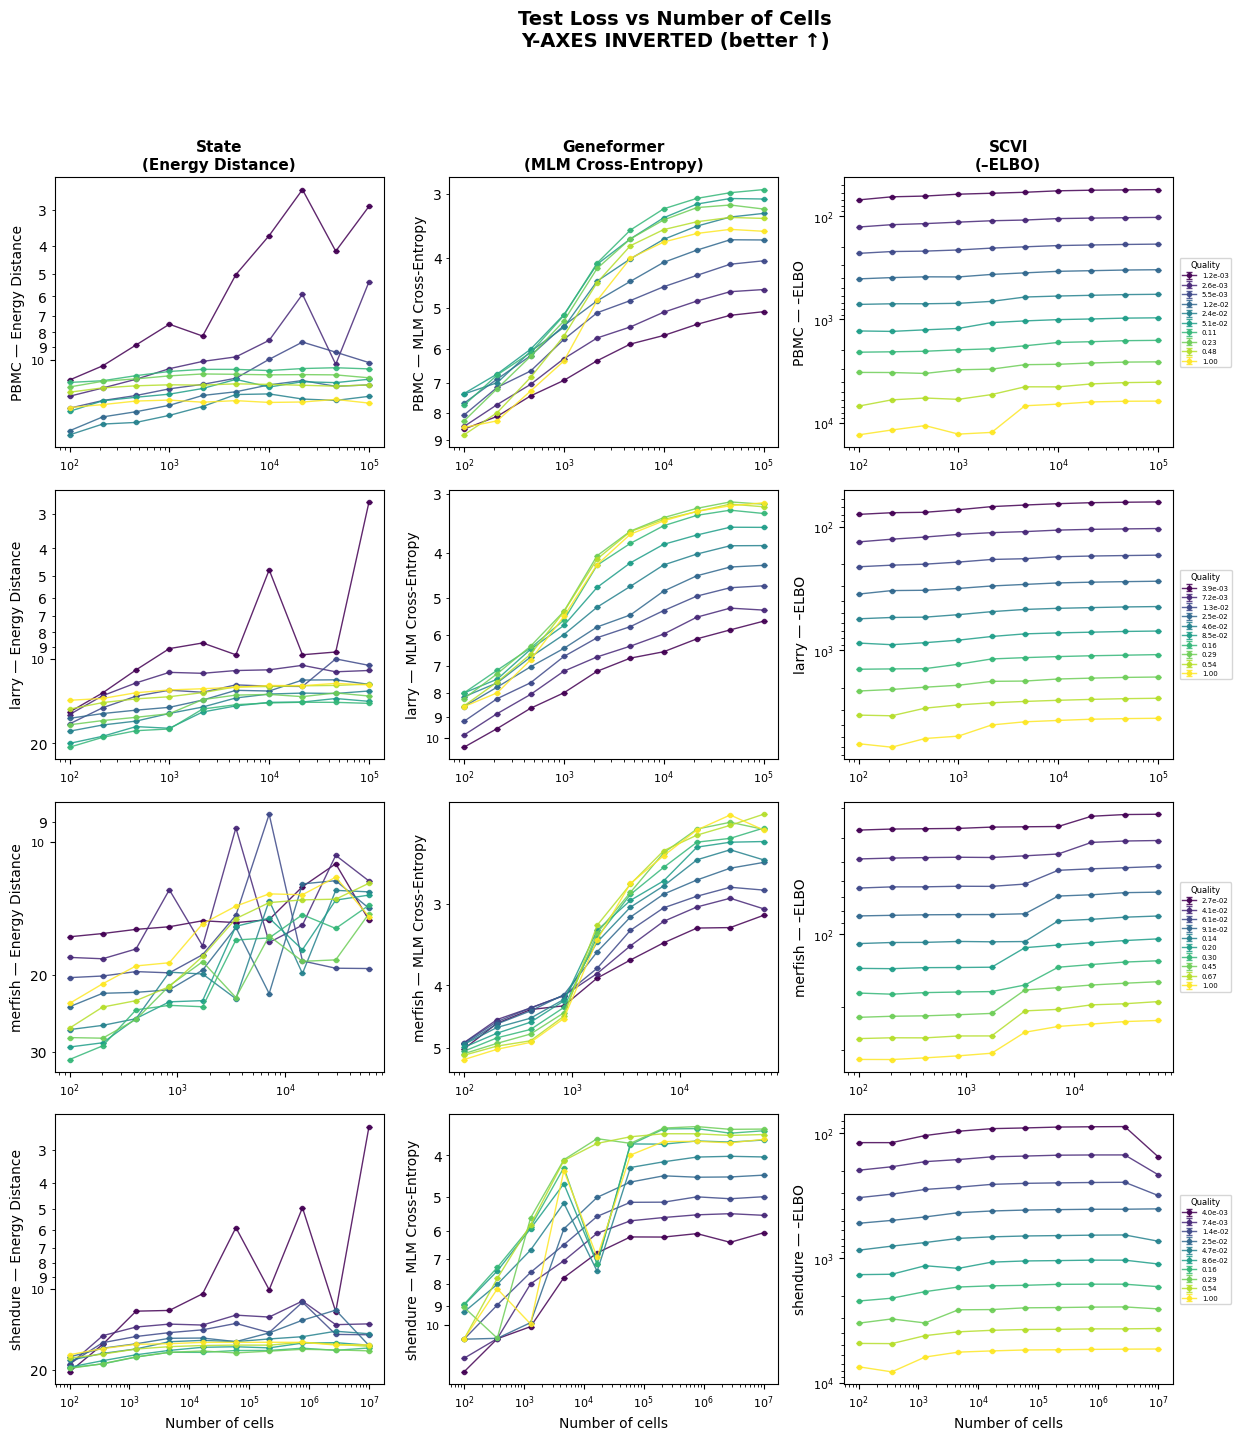

In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

ALGO_ORDER = ['State', 'Geneformer', 'SCVI']

# Per-algorithm loss description for axis labels and titles
ALGO_LOSS_LABEL = {
    'State':      'Energy Distance',
    'Geneformer': 'MLM Cross-Entropy',
    'SCVI':       '\u2013ELBO',
}

def _fmt_size(sz):
    if sz >= 1_000_000:
        return f'{sz/1_000_000:.0f}M' if sz % 1_000_000 == 0 else f'{sz/1_000_000:.1f}M'
    if sz >= 1_000:
        return f'{sz/1_000:.0f}k' if sz % 1_000 == 0 else f'{sz/1_000:.1f}k'
    return str(sz)

def _fmt_quality(q):
    """Format quality in log-friendly notation: 1.2e-3, 0.10, 1.00."""
    if q >= 0.1:
        return f'{q:.2f}'
    return f'{q:.1e}'

def _plain_number(x, pos):
    if x == 0:
        return '0'
    return f'{x:g}'

def plot_loss_scaling(df):
    """Plot test loss vs cell number: rows=dataset, cols=algorithm, curves=quality.
    For SCVI, plot -ELBO (positive) so log scale works.
    Y-axes are inverted so that better (lower) values appear at the top."""
    all_datasets = sorted(df['dataset'].unique())
    algorithms = [a for a in ALGO_ORDER if a in df['algorithm'].unique()]
    n_rows = len(all_datasets)
    n_cols = len(algorithms)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols + 1.6, 3.5 * n_rows + 0.8),
                             squeeze=False, sharex=False)

    cmap = plt.cm.viridis
    plain_fmtr = mticker.FuncFormatter(_plain_number)

    for i, ds in enumerate(all_datasets):
        # Color by quality for this dataset
        qualities = sorted(df[df['dataset'] == ds]['quality'].unique())
        if qualities:
            q_norm = mcolors.LogNorm(vmin=min(qualities), vmax=max(qualities))

        for j, algo in enumerate(algorithms):
            ax = axes[i, j]
            sub = df[(df['dataset'] == ds) & (df['algorithm'] == algo)]
            loss_label = ALGO_LOSS_LABEL.get(algo, 'Loss')

            if sub.empty:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                        transform=ax.transAxes, color='gray', fontsize=10)
            else:
                negate = (algo == 'SCVI')
                for q in sorted(sub['quality'].unique()):
                    color = cmap(q_norm(q))
                    q_df = sub[sub['quality'] == q]
                    agg = q_df.groupby('size')['loss_value'].agg(['mean', 'std', 'count']).reset_index()
                    agg = agg.sort_values('size')
                    agg['sem'] = (agg['std'] / np.sqrt(agg['count'])).fillna(0)
                    y = -agg['mean'] if negate else agg['mean']
                    ax.errorbar(agg['size'], y, yerr=agg['sem'],
                                marker='o', markersize=3, linewidth=1, capsize=2,
                                color=color, alpha=0.85, label=_fmt_quality(q))

            ax.set_xscale('log')
            ax.set_yscale('log')

            if algo in ('State', 'Geneformer'):
                ax.yaxis.set_major_formatter(plain_fmtr)
                ax.yaxis.set_minor_formatter(plain_fmtr)
            else:
                ax.yaxis.set_minor_formatter(mticker.NullFormatter())

            ax.invert_yaxis()

            if i == n_rows - 1:
                ax.set_xlabel('Number of cells', fontsize=10)
            ax.set_ylabel(f'{ds} \u2014 {loss_label}', fontsize=10)
            if i == 0:
                ax.set_title(f'{algo}\n({loss_label})', fontsize=11, fontweight='bold')
            ax.tick_params(labelsize=8)

        # Legend to the right of the last column for this row
        last_ax = axes[i, n_cols - 1]
        handles, labels = last_ax.get_legend_handles_labels()
        if handles:
            last_ax.legend(handles, labels, title='Quality', fontsize=5,
                           title_fontsize=6, loc='center left',
                           bbox_to_anchor=(1.02, 0.5), borderaxespad=0,
                           frameon=True, framealpha=0.8)

    fig.suptitle('Test Loss vs Number of Cells\nY-AXES INVERTED (better \u2191)',
                 fontsize=14, fontweight='bold')
    fig.tight_layout(rect=[0, 0.01, 0.92, 0.94])
    plt.show()
    return fig

fig = plot_loss_scaling(df_results)